In [116]:
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [117]:
ds1 = xr.open_dataset("~/WPS/geo_em.d01.nc")
ds2 = xr.open_dataset("~/WPS/geo_em.d02.nc")

ke = gpd.read_file("../kenya Map/ke.json")
ke = ke.to_crs(epsg=4326)

In [118]:
print(ke.columns)

Index(['source', 'id', 'name', 'geometry'], dtype='object')


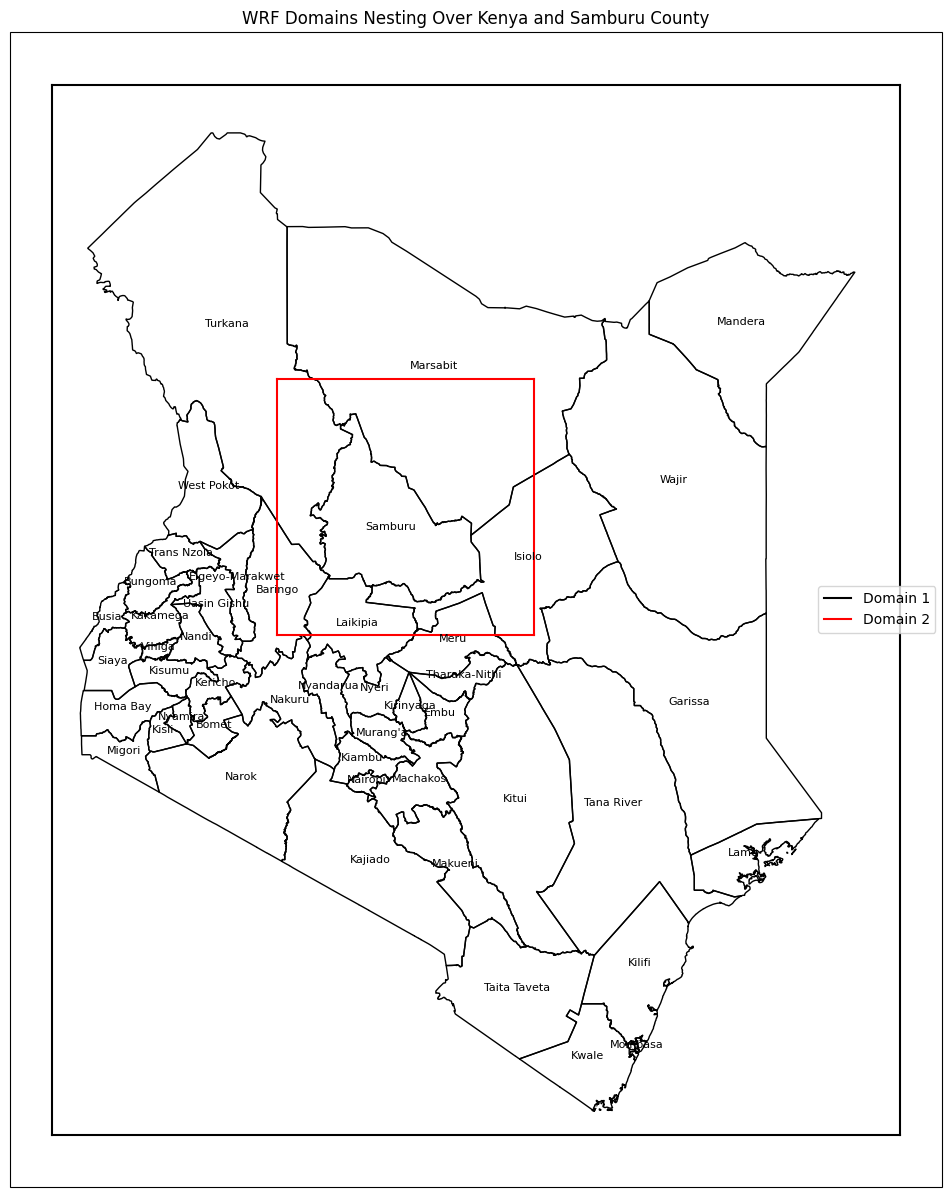

In [119]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(18,15))
ax = plt.axes(projection=proj)

ke.boundary.plot(
    ax=ax,
    edgecolor = "black", 
    linewidth=1,
    transform = proj
    )


for idx, row in ke.iterrows():
    plt.annotate(text=row['name'], xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                 ha='center', fontsize=8, transform=proj)


ax.plot(ds1.XLONG_M[0,:,0], ds1.XLAT_M[0,:,0], "k", transform=proj, label="Domain 1")
ax.plot(ds1.XLONG_M[0,:,-1], ds1.XLAT_M[0,:,-1], "k", transform=proj)
ax.plot(ds1.XLONG_M[0,0,:], ds1.XLAT_M[0,0,:,], "k", transform=proj)
ax.plot(ds1.XLONG_M[0,-1,:], ds1.XLAT_M[0,-1,:,], "k", transform=proj)

ax.plot(ds2.XLONG_M[0,:,0], ds2.XLAT_M[0,:,0], "r", transform=proj, label="Domain 2")
ax.plot(ds2.XLONG_M[0,:,-1], ds2.XLAT_M[0,:,-1], "r", transform=proj)
ax.plot(ds2.XLONG_M[0,0,:], ds2.XLAT_M[0,0,:,], "r", transform=proj)
ax.plot(ds2.XLONG_M[0,-1,:], ds2.XLAT_M[0,-1,:,], "r", transform=proj)



ax.set_title("WRF Domains Nesting Over Kenya and Samburu County")
ax.legend()
fig.savefig('wrf_domains.png', dpi=300, bbox_inches='tight')
plt.show()